# Notebook 2 — Phrase Visualization & Playback

Goal: take phrase segments from the Jazzomat DB and render them as:
- **MIDI** (playable inline audio)
- **Sheet music** (via music21 + MuseScore/LilyPond if available)

Source: `melody` table (pitch, onset, duration in seconds; fractional MIDI pitch)

In [1]:
import sqlite3
import os
import pandas as pd
import pretty_midi
import numpy as np
from IPython.display import display, Audio
from pathlib import Path

# Locate DB (primary: ../data relative to this notebook runtime location).
db_name = 'wjazzd.db'
candidate_paths = [
    Path('../data') / db_name,
    Path('data') / db_name,
    Path(db_name),
    Path('../' + db_name),
]

# Optional explicit override: set JAZZOMAT_DB_PATH in your environment.
env_db = os.getenv('JAZZOMAT_DB_PATH')
if env_db:
    candidate_paths.insert(0, Path(env_db).expanduser())

for candidate in candidate_paths:
    if candidate.expanduser().exists():
        DB_PATH = candidate.expanduser().resolve()
        break
else:
    checked = '\n'.join(f'- {p.expanduser()}' for p in candidate_paths)
    raise FileNotFoundError(f'wjazzd.db not found. Checked:\n{checked}')

conn = sqlite3.connect(DB_PATH)
print(f'Connected to {DB_PATH}')

Connected to C:\Users\grego\Documents\GitHub\jazzomat-app\data\wjazzd.db


## 1. Pick a phrase to visualize

We'll pick the first phrase from the preview CSV (or query the DB directly). You can change `TARGET_PHRASE_UID` to any `phrase_uid` from notebook 1.

In [8]:
# Load phrase segments from notebook 1 output
SEGMENTS_CSV = Path('../data/phrase_segments_preview.csv')
segments = pd.read_csv(SEGMENTS_CSV)

# Pick a random phrase each run
if segments.empty:
    raise ValueError("No rows found in segments CSV.")

phrase = segments.sample(n=1).iloc[0]
TARGET_PHRASE_UID = str(phrase['phrase_uid'])
melid = int(phrase['melid'])
start_idx = int(phrase['phrase_start_idx'])
end_idx   = int(phrase['phrase_end_idx'])

# Tonal and meter metadata from notebook 1 export (if available)
SOLO_KEY = str(phrase.get('solo_key', '')).strip()
METER_SIGNATURE = str(phrase.get('meter_signature', '')).strip()

# Instrument-aware transposition for written part (concert -> written)
instrument_code = str(phrase.get('instrument', '')).strip().lower()
AUTO_TRANSPOSE_SEMITONES_BY_INSTRUMENT = {
    'tp': 2,   # Bb trumpet
    'cl': 2,   # Bb clarinet
    'ss': 2,   # soprano sax (Bb)
    'ts': 14,  # tenor sax (Bb, written M9 above concert)
    'as': 9,   # alto sax (Eb, written M6 above concert)
    'bs': 21,  # bari sax (Eb, written M13 above concert)
}
MANUAL_TRANSPOSE_SEMITONES = None  # set int (e.g., 2) to override auto
TRANSPOSE_SEMITONES = AUTO_TRANSPOSE_SEMITONES_BY_INSTRUMENT.get(instrument_code, 0)
if MANUAL_TRANSPOSE_SEMITONES is not None:
    TRANSPOSE_SEMITONES = int(MANUAL_TRANSPOSE_SEMITONES)

print(f"Performer   : {phrase['performer']}")
print(f"Instrument  : {phrase.get('instrument', 'unknown')}")
print(f"Solo        : {phrase['solo_title']}")
print(f"Key         : {SOLO_KEY if SOLO_KEY else 'unknown'}")
print(f"Meter       : {METER_SIGNATURE if METER_SIGNATURE else 'unknown'}")
print(f"Chords      : {phrase['chords']}")
print(f"Notes       : {phrase['note_count']}  |  melid={melid}, events [{start_idx},{end_idx}]")
print(f"Transpose   : {TRANSPOSE_SEMITONES:+d} semitones (concert -> written)")

Performer   : Pat Metheny
Instrument  : g
Solo        : All the Things You Are
Key         : F-maj
Meter       : 4/4
Chords      : C-7 | F-7 | Bb7
Notes       : 28  |  melid=342, events [209,237]
Transpose   : +0 semitones (concert -> written)


## 2. Fetch melody events for this phrase

In [9]:
# Fetch note events in event order (matches phrase indices from notebook 1).
query = """
    SELECT eventid, onset, pitch, duration, bar, beat, beatdur, num, denom
    FROM melody
    WHERE melid = ?
    ORDER BY eventid
"""
all_notes = pd.read_sql(query, conn, params=(melid,))

# phrase_start/end_idx are 0-based indices from notebook 1; end is exclusive in segmentation join logic
phrase_notes = all_notes.iloc[start_idx:end_idx].reset_index(drop=True).copy()
if phrase_notes.empty:
    raise ValueError(f'Phrase {TARGET_PHRASE_UID} has no notes after slicing [{start_idx}:{end_idx}]')

# Attach beat-grid context (chord/form/signature/beat position)
beats_q = """
    SELECT melid, onset AS beat_onset, bar AS beat_bar, beat AS beat_in_bar, signature, chord, form, chorus_id
    FROM beats
    WHERE melid = ?
    ORDER BY onset
"""
beats_ctx = pd.read_sql(beats_q, conn, params=(melid,))

if not beats_ctx.empty:
    phrase_notes = pd.merge_asof(
        phrase_notes.sort_values('onset'),
        beats_ctx.drop(columns=['melid']).sort_values('beat_onset'),
        left_on='onset',
        right_on='beat_onset',
        direction='backward',
    ).sort_values('eventid').reset_index(drop=True)
else:
    phrase_notes['beat_onset'] = np.nan
    phrase_notes['beat_bar'] = np.nan
    phrase_notes['beat_in_bar'] = np.nan
    phrase_notes['signature'] = np.nan
    phrase_notes['chord'] = np.nan
    phrase_notes['form'] = np.nan
    phrase_notes['chorus_id'] = np.nan

# Round fractional MIDI to nearest semitone for playback/notation
phrase_notes['pitch_int'] = phrase_notes['pitch'].round().astype(int)

# Relative onset for MIDI playback
phrase_notes['onset_rel'] = phrase_notes['onset'] - phrase_notes['onset'].iloc[0]

# Bar-anchored onset for notation: preserve pickup/entry rests from bar start
if not beats_ctx.empty and pd.notna(phrase_notes.loc[0, 'beat_bar']):
    first_bar = int(phrase_notes.loc[0, 'beat_bar'])
    bar_start_onset = beats_ctx.loc[beats_ctx['beat_bar'] == first_bar, 'beat_onset'].min()
else:
    bar_start_onset = phrase_notes['onset'].iloc[0]
phrase_notes['onset_from_bar_start'] = phrase_notes['onset'] - bar_start_onset

phrase_notes[['eventid', 'bar', 'beat', 'beat_in_bar', 'signature', 'chord', 'onset_from_bar_start', 'onset_rel', 'duration', 'pitch_int']]

,eventid,bar,beat,beat_in_bar,signature,chord,onset_from_bar_start,onset_rel,duration,pitch_int
0,155655,44,2,2,,,0.202154,0.000000,0.073469,55
1,155656,44,2,2,,,0.279705,0.077551,0.081633,57
2,155657,44,2,2,,,0.361338,0.159184,0.077551,59
3,155658,44,3,3,,,0.447052,0.244898,0.114286,60
4,155659,44,4,3,,,0.561338,0.359184,0.097959,59
5,155660,44,4,4,,,0.671542,0.469388,0.077551,58
6,155661,45,1,4,,,0.753175,0.551020,0.089796,57
7,155662,45,1,1,,C-7,0.863379,0.661224,0.097959,56
8,155663,45,2,2,,,0.981746,0.779592,0.081633,55
9,155664,45,2,2,,,1.075624,0.873469,0.081633,51


## 3. Build a MIDI file with `pretty_midi`

In [10]:
def phrase_to_midi(notes_df: pd.DataFrame, tempo_bpm: float = 120.0) -> pretty_midi.PrettyMIDI:
    """Convert a DataFrame of phrase notes to a PrettyMIDI object.
    Columns needed: onset_rel (sec), pitch_int (MIDI int), duration (sec).
    """
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo_bpm)
    instrument = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program('Acoustic Grand Piano'),
        name='phrase'
    )
    for _, row in notes_df.iterrows():
        start = float(row['onset_rel'])
        end   = start + max(float(row['duration']), 0.05)  # avoid zero-length notes
        note  = pretty_midi.Note(
            velocity=80,
            pitch=int(row['pitch_int']),
            start=start,
            end=end
        )
        instrument.notes.append(note)
    pm.instruments.append(instrument)
    return pm


pm = phrase_to_midi(phrase_notes)

# Save MIDI to disk
out_dir = Path('../data')
out_dir.mkdir(exist_ok=True)
midi_path = out_dir / f'phrase_{TARGET_PHRASE_UID}.mid'
pm.write(str(midi_path))
print(f'MIDI saved → {midi_path.resolve()}')

MIDI saved → C:\Users\grego\Documents\GitHub\jazzomat-app\data\phrase_342_209_237.mid


## 5. Sheet music notation with `music21` + MIDI Playback

Converts the phrase to a `music21` Stream and renders notation.  
Requires **MuseScore** or **LilyPond** installed for inline image rendering — if neither is present, a text representation is shown instead.

Chord event labels: ['C-7', 'F-7', 'Bb7']
Notation PNG saved -> C:\Users\grego\Documents\GitHub\jazzomat-app\data\phrase_342_209_237_notation-1.png
Time signature: 4/4 | Quantization: (2, 4) | Quarter(sec): 0.196 | Transpose mode: ALL | Applied transpose: +0 st | Chords: 3
Concert key: F-maj | Written key: F major


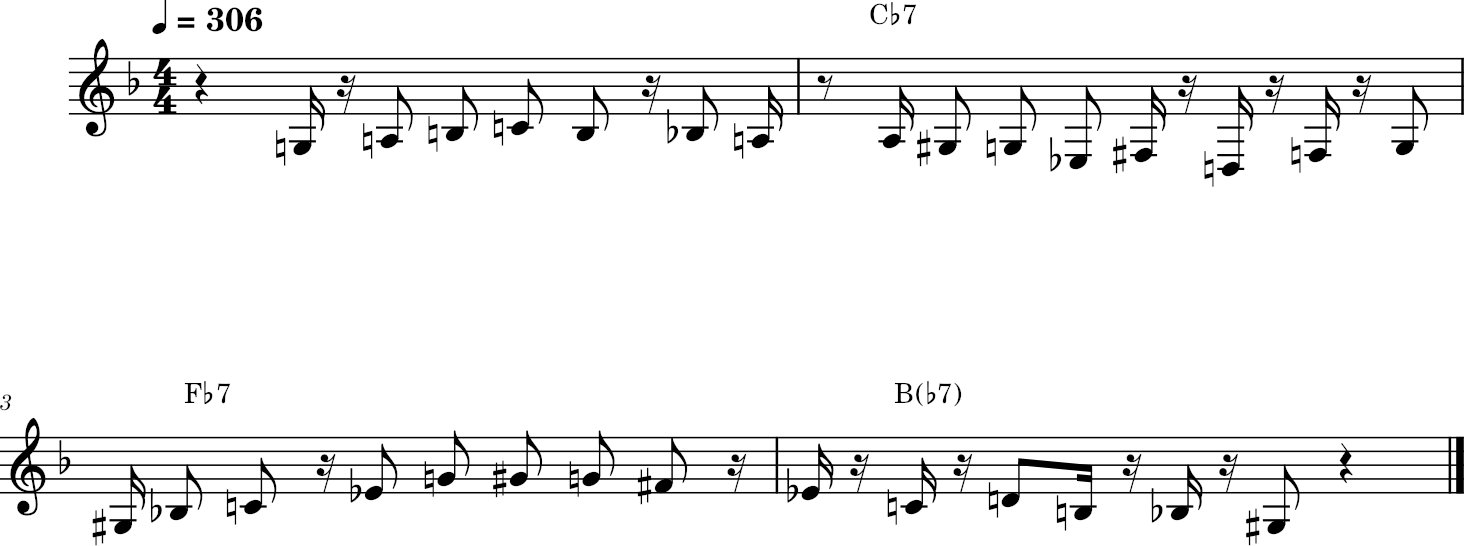

Rendered with built-in sine synthesizer (install fluidsynth for realistic sound)


In [11]:
import shutil
import music21 as m21
from IPython.display import Image, display

def _find_musescore_exe() -> str | None:
    for exe in ["musescore", "musescore4", "mscore", "mscore4", "MuseScore4"]:
        found = shutil.which(exe)
        if found:
            return found
    for c in [
        Path("C:/Program Files/MuseScore 4/bin/MuseScore4.exe"),
        Path("C:/Program Files/MuseScore 3/bin/MuseScore3.exe"),
        Path("C:/Program Files (x86)/MuseScore 3/bin/MuseScore3.exe"),
    ]:
        if c.exists():
            return str(c)
    return None

def _pick_time_signature(notes_df: pd.DataFrame, fallback: str = "4/4") -> str:
    sig_series = notes_df.get('signature')
    if sig_series is None:
        return fallback
    valid = [str(s).strip() for s in sig_series.dropna() if str(s).strip()]
    return valid[0] if valid else fallback

def _parse_db_key_to_music21(key_text: str):
    """Convert DB key labels like Bb-maj / F#-min into a music21 Key object."""
    txt = str(key_text).strip()
    if not txt:
        return None
    parts = txt.split('-', 1)
    if len(parts) != 2:
        return None

    tonic_raw, mode_raw = parts[0].strip(), parts[1].strip().lower()
    mode_map = {'maj': 'major', 'min': 'minor'}
    mode = mode_map.get(mode_raw, mode_raw)
    tonic = tonic_raw.replace('b', '-')

    try:
        return m21.key.Key(tonic, mode)
    except Exception:
        return None

def _simple_chord_events(notes_df: pd.DataFrame, qdur_sec: float) -> list[tuple[float, str]]:
    if 'chord' not in notes_df.columns:
        return []
    events: list[tuple[float, str]] = []
    prev = None
    for _, row in notes_df.sort_values('onset_from_bar_start').iterrows():
        chord = row.get('chord')
        if pd.isna(chord):
            continue
        label = str(chord).strip()
        if not label or label == prev:
            continue
        offset_sec = float(row['onset_from_bar_start']) if pd.notna(row.get('onset_from_bar_start')) else float(row['onset_rel'])
        events.append((max(offset_sec / qdur_sec, 0.0), label))
        prev = label
    return events

def _insert_chords_above_staff(
    score: m21.stream.Stream,
    chord_events: list[tuple[float, str]],
    transpose_semitones: int = 0,
 ) -> int:
    """Insert chord symbols into measure-local offsets for above-staff rendering."""
    measures = list(score.getElementsByClass(m21.stream.Measure))
    if not measures:
        return 0

    ts = measures[0].timeSignature
    bar_ql = float(ts.barDuration.quarterLength) if ts is not None else 4.0

    inserted = 0
    for offset_q, label in chord_events:
        measure_number = int(offset_q // bar_ql) + 1
        local_offset = float(offset_q % bar_ql)
        m = score.measure(measure_number)
        if m is None:
            continue
        try:
            cs = m21.harmony.ChordSymbol(label)
            if int(transpose_semitones) != 0:
                cs = cs.transpose(int(transpose_semitones), inPlace=False)
            cs.placement = 'above'
            m.insert(local_offset, cs)
            inserted += 1
        except Exception:
            pass
    return inserted

def phrase_to_stream_notated(
    notes_df: pd.DataFrame,
    quarter_duration_sec: float,
    time_signature: str,
    key_text: str = '',
    quantize_divisors: tuple[int, ...] = (2, 4),
    transpose_semitones: int = 0,
    include_chords: bool = True,
 ) -> tuple[m21.stream.Stream, int, str]:
    """Simple music21 engraving pipeline: notes -> quantize -> measures -> rests/ties/beams."""
    qdur_sec = max(float(quarter_duration_sec), 1e-6)

    part = m21.stream.Part()
    part.append(m21.clef.TrebleClef())
    part.append(m21.meter.TimeSignature(time_signature))

    key_obj = _parse_db_key_to_music21(key_text)
    written_key_label = ''
    if key_obj is not None:
        if int(transpose_semitones) != 0:
            key_obj = key_obj.transpose(int(transpose_semitones))
        part.append(key_obj)
        written_key_label = f'{key_obj.tonic.name} {key_obj.mode}'

    bpm = round(60 / qdur_sec) if qdur_sec > 0 else 120
    part.append(m21.tempo.MetronomeMark(number=bpm))

    for _, row in notes_df.sort_values('onset_from_bar_start').iterrows():
        offset_sec = float(row['onset_from_bar_start']) if pd.notna(row.get('onset_from_bar_start')) else float(row['onset_rel'])
        offset_q = max(offset_sec / qdur_sec, 0.0)
        dur_q = max(float(row['duration']) / qdur_sec, 0.25)
        n = m21.note.Note(int(row['pitch_int']) + int(transpose_semitones))
        n.duration = m21.duration.Duration(dur_q)
        part.insert(offset_q, n)

    quantized = part.quantize(
        quarterLengthDivisors=quantize_divisors,
        processOffsets=True,
        processDurations=True,
        inPlace=False,
    )
    score = quantized.makeMeasures(inPlace=False)
    score.makeRests(fillGaps=True, inPlace=True)
    score.makeTies(inPlace=True)
    score.makeBeams(inPlace=True)
    score = score.makeNotation(inPlace=False, bestClef=False)

    inserted_chords = 0
    if include_chords:
        events = _simple_chord_events(notes_df, qdur_sec=qdur_sec)
        inserted_chords = _insert_chords_above_staff(score, events, transpose_semitones=transpose_semitones)

    score.insert(0, m21.clef.TrebleClef())
    return score, inserted_chords, written_key_label

# Controls
QUANTIZE_DIVISORS = (2, 4)
FALLBACK_SIGNATURE = str(globals().get('METER_SIGNATURE', '')).strip() or '4/4'
TIME_SIGNATURE = _pick_time_signature(phrase_notes, fallback=FALLBACK_SIGNATURE)
KEY_TEXT = str(globals().get('SOLO_KEY', '')).strip()
TRANSPOSE_SEMITONES = int(globals().get('TRANSPOSE_SEMITONES', 0))
TRANSPOSE_ALL = bool(globals().get('TRANSPOSE_ALL', True))
EFFECTIVE_TRANSPOSE_SEMITONES = TRANSPOSE_SEMITONES if TRANSPOSE_ALL else 0
INCLUDE_CHORDS = True

if 'beatdur' in phrase_notes.columns and phrase_notes['beatdur'].notna().any():
    quarter_dur = float(phrase_notes['beatdur'].dropna().median())
else:
    ioi = phrase_notes['onset_rel'].diff().dropna()
    median_ioi = ioi.median() if len(ioi) > 1 else 0.5
    quarter_dur = float(median_ioi) if pd.notnull(median_ioi) else 0.5

stream, inserted_chords, written_key_label = phrase_to_stream_notated(
    phrase_notes,
    quarter_duration_sec=quarter_dur,
    time_signature=TIME_SIGNATURE,
    key_text=KEY_TEXT,
    quantize_divisors=QUANTIZE_DIVISORS,
    transpose_semitones=EFFECTIVE_TRANSPOSE_SEMITONES,
    include_chords=INCLUDE_CHORDS,
 )

chord_events_preview = _simple_chord_events(phrase_notes, qdur_sec=max(float(quarter_dur), 1e-6))
print('Chord event labels:', [lbl for _, lbl in chord_events_preview])

us = m21.environment.UserSettings()
musescore_exe = _find_musescore_exe()
if musescore_exe:
    us['musescoreDirectPNGPath'] = musescore_exe
    us['musicxmlPath'] = musescore_exe

out_dir = Path('../data')
out_dir.mkdir(exist_ok=True)

try:
    png_path = out_dir / f'phrase_{TARGET_PHRASE_UID}_notation.png'
    written = stream.write('musicxml.png', fp=str(png_path))
    print(f'Notation PNG saved -> {Path(written).resolve()}')
    print(
        f'Time signature: {TIME_SIGNATURE} | Quantization: {QUANTIZE_DIVISORS} | '
        f'Quarter(sec): {quarter_dur:.3f} | Transpose mode: {'ALL' if TRANSPOSE_ALL else 'NONE'} | '
        f'Applied transpose: {EFFECTIVE_TRANSPOSE_SEMITONES:+d} st | Chords: {inserted_chords}'
    )
    print(
        f'Concert key: {KEY_TEXT if KEY_TEXT else "unknown"} | '
        f'Written key: {written_key_label if written_key_label else "unknown"}'
    )
    display(Image(filename=str(written)))
except Exception as e:
    xml_path = out_dir / f'phrase_{TARGET_PHRASE_UID}.musicxml'
    written_xml = stream.write('musicxml', fp=str(xml_path))
    print(f'Could not render PNG inline: {e}')
    print(f'Exported MusicXML -> {Path(written_xml).resolve()}')
    if not musescore_exe:
        print('MuseScore was not found. Install MuseScore and rerun this cell for inline notation PNG.')

try:
    audio = pm.fluidsynth(fs=22050)
    print('Rendered with FluidSynth')
except Exception:
    audio = pm.synthesize(fs=22050)
    print('Rendered with built-in sine synthesizer (install fluidsynth for realistic sound)')

display(Audio(audio, rate=22050))

## 6. Configure MuseScore (one-time setup)

Run the cell below **once** after installing MuseScore to let music21 find it.

In [6]:
# Uncomment and run once after installing MuseScore:
# m21.configure.run()

## 7. Explore other phrases

Change `TARGET_PHRASE_UID` in cell 3 to any value from the segments table and re-run.

In [7]:
# Quick look at available phrases
segments[['phrase_uid', 'performer', 'solo_title', 'note_count', 'chords']].head(20)

,phrase_uid,performer,solo_title,note_count,chords
0,1_0_6,Art Pepper,Anthropology,6,Bb6
1,1_7_34,Art Pepper,Anthropology,27,G-7 | C-7 | F7 | F-7 | Bb7 | Eb7 | Ab7 | D-7
2,1_35_46,Art Pepper,Anthropology,11,Bb6 | G7 | C-7 | F7
3,1_47_73,Art Pepper,Anthropology,26,G-7 | C-7 | F7 | F-7 | Bb7 | Eb7
4,1_74_75,Art Pepper,Anthropology,1,NaN
5,1_76_79,Art Pepper,Anthropology,3,NaN
6,1_80_84,Art Pepper,Anthropology,4,NaN
7,1_85_94,Art Pepper,Anthropology,9,NaN
8,1_95_103,Art Pepper,Anthropology,8,NaN
9,1_104_110,Art Pepper,Anthropology,6,G7 | C-7 | F7
